# Regresión Logística Bayesiana: De la Prior a la Posterior

La regresión logística bayesiana incorpora la incertidumbre y conocimiento previo en los parámetros del modelo mediante el uso de distribuciones previas y la verosimilitud de los datos observados. El objetivo es encontrar la distribución posterior para los coeficientes de la regresión. 

En este documento, mostraremos paso a paso cómo se deriva la posterior en la regresión logística bayesiana, asumiendo que $\sigma$ no es conocido.

## 1. Modelo Logístico

El modelo de regresión logística es:

$$
P(Y_i = 1 \mid X_i, \beta) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \dots + \beta_p X_{ip})}}
$$

Donde:
- $Y_i$ es una variable binaria que toma valores 0 o 1.
- $X_i = (1, X_{i1}, X_{i2}, \dots, X_{ip})$ es el vector de variables independientes del i-ésimo individuo.
- $\beta = (\beta_0, \beta_1, \dots, \beta_p)$ es el vector de coeficientes que queremos estimar.

Queremos encontrar la distribución posterior para los coeficientes $\beta$ dados los datos observados.

## 2. Prior (Distribución previa)

En el enfoque bayesiano, asumimos una distribución previa para los coeficientes $\beta$. Dado que $\sigma$ no es conocido, asumiremos una **distribución normal** para cada coeficiente con una varianza desconocida, lo que implica que vamos a utilizar una prior conjunta para $\beta$ y $\sigma$:

$$
\beta_j \mid \sigma^2 \sim \mathcal{N}(0, \sigma^2) \quad \text{para } j = 0, 1, \dots, p
$$

Para la varianza $\sigma^2$, asumimos una distribución **inversa-gamma**, que es común para modelar la incertidumbre sobre una varianza desconocida:

$$
\sigma^2 \sim \text{Inv-Gamma}(\alpha, \beta)
$$

Por lo tanto, la prior conjunta para $\beta$ y $\sigma^2$ es:

$$
P(\beta, \sigma^2) = P(\beta \mid \sigma^2) P(\sigma^2)
$$

Donde:
- $P(\beta \mid \sigma^2) = \prod_{j=0}^{p} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{\beta_j^2}{2\sigma^2}\right)$
- $P(\sigma^2) = \frac{\beta^\alpha}{\Gamma(\alpha)} (\sigma^2)^{-\alpha-1} \exp\left(-\frac{\beta}{\sigma^2}\right)$

## 3. Likelihood (Verosimilitud)

La verosimilitud describe cómo los datos observados se relacionan con los parámetros del modelo. Dado que estamos trabajando con una regresión logística, la verosimilitud para una sola observación $(Y_i, X_i)$ es:

$$
P(Y_i \mid X_i, \beta) = \left(\frac{1}{1 + e^{-X_i^\top \beta}}\right)^{Y_i} \left(1 - \frac{1}{1 + e^{-X_i^\top \beta}}\right)^{1 - Y_i}
$$

Para un conjunto de datos $(Y_1, \dots, Y_n)$ independientes, la verosimilitud completa es el producto de las probabilidades individuales:

$$
P(Y \mid X, \beta) = \prod_{i=1}^{n} \left(\frac{1}{1 + e^{-X_i^\top \beta}}\right)^{Y_i} \left(1 - \frac{1}{1 + e^{-X_i^\top \beta}}\right)^{1 - Y_i}
$$

## 4. Posterior (Distribución posterior)

El teorema de Bayes nos permite calcular la distribución posterior de los parámetros dados los datos:

$$
P(\beta, \sigma^2 \mid Y, X) = \frac{P(Y \mid X, \beta) P(\beta, \sigma^2)}{P(Y \mid X)}
$$

Donde:
- $P(\beta, \sigma^2 \mid Y, X)$ es la posterior, que es lo que queremos encontrar.
- $P(Y \mid X, \beta)$ es la verosimilitud calculada previamente.
- $P(\beta, \sigma^2)$ es la prior conjunta.
- $P(Y \mid X)$ es la evidencia o probabilidad marginal de los datos:

$$
P(Y \mid X) = \int \int P(Y \mid X, \beta) P(\beta \mid \sigma^2) P(\sigma^2) \, d\beta \, d\sigma^2
$$

Esta integral es compleja y, generalmente, no tiene una forma analítica. Por ello, en la práctica, utilizamos métodos numéricos, como el **Markov Chain Monte Carlo (MCMC)**, para aproximar la distribución posterior.

## 5. Resumen de la Derivación

Para encontrar la distribución posterior en la regresión logística bayesiana, seguimos estos pasos:

1. **Prior**: Seleccionamos una distribución normal para los coeficientes $\beta_j$ y una inversa-gamma para la varianza $\sigma^2$.
2. **Verosimilitud**: Modelamos la probabilidad de los datos usando la función logística.
3. **Posterior**: Combinamos la prior conjunta y la verosimilitud usando el teorema de Bayes para obtener la distribución posterior conjunta de los coeficientes y la varianza.

### 6. Implementación Práctica

Para obtener la posterior de $\beta$ y $\sigma^2$, podemos usar librerías de programación bayesiana como PyMC3, NumPyro o Stan. Estas librerías implementan métodos como MCMC para aproximar la distribución posterior.

### Nota sobre la Interpretación

Una vez que tenemos la posterior, podemos calcular intervalos de credibilidad para los coeficientes $\beta_j$ y la varianza $\sigma^2$, realizar predicciones y analizar la incertidumbre en nuestras estimaciones.


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

from scipy.special import expit as inverse_logit
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
# Number of data points
n = 250
# Create features
x1 = rng.normal(loc=0.0, scale=2.0, size=n)
x2 = rng.normal(loc=0.0, scale=2.0, size=n)
# Define target variable
intercept = -0.5
beta_x1 = 1
beta_x2 = -1
beta_interaction = 2
z = intercept + beta_x1 * x1 + beta_x2 * x2 + beta_interaction * x1 * x2
p = inverse_logit(z)
# note binomial with n=1 is equal to a Bernoulli
y = rng.binomial(n=1, p=p, size=n)
df = pd.DataFrame(dict(x1=x1, x2=x2, y=y))
df.head()

,x1,x2,y
0,-0.445284,1.381325,0
1,2.651317,0.800736,1
2,-1.141940,-0.128204,0
3,1.336498,-0.931965,0
4,2.290762,3.400222,1


/opt/homebrew/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


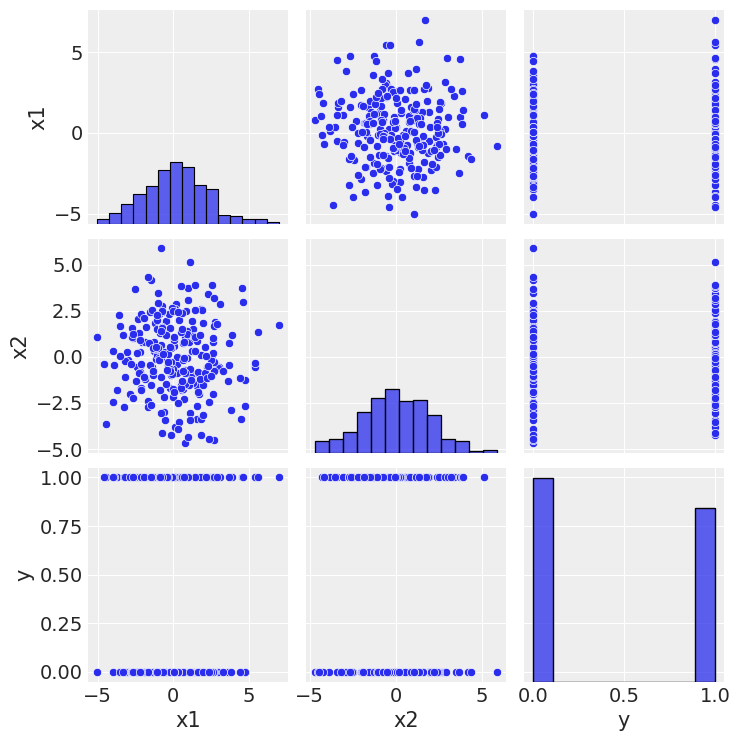

In [4]:
sns.pairplot(data=df, kind="scatter");

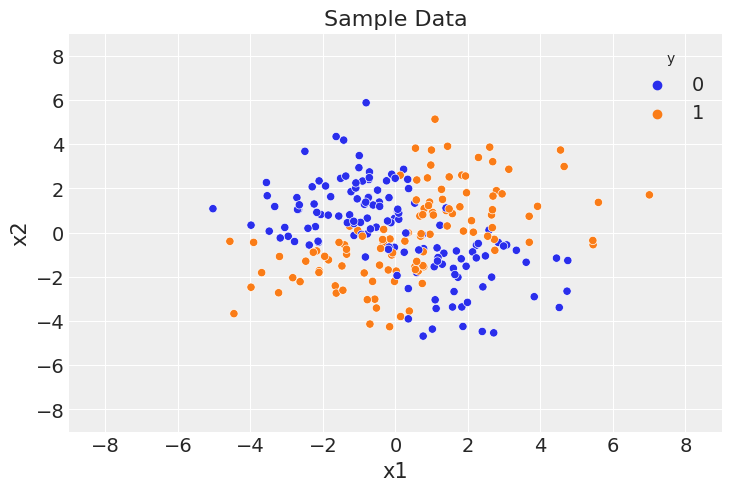

In [5]:
fig, ax = plt.subplots()
sns.scatterplot(x="x1", y="x2", data=df, hue="y")
ax.legend(title="y")
ax.set(title="Sample Data", xlim=(-9, 9), ylim=(-9, 9));

In [6]:
labels = ["Intercept", "x1", "x2", "x1:x2"]
df["Intercept"] = np.ones(len(df))
df["x1:x2"] = df["x1"] * df["x2"]
# reorder columns to be in the same order as labels
df = df[labels]
x = df.to_numpy()

In [7]:
indices = rng.permutation(x.shape[0])
train_prop = 0.7
train_size = int(train_prop * x.shape[0])
training_idx, test_idx = indices[:train_size], indices[train_size:]
x_train, x_test = x[training_idx, :], x[test_idx, :]
y_train, y_test = y[training_idx], y[test_idx]

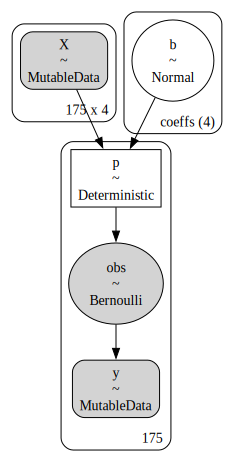

In [8]:
coords = {"coeffs": labels}

with pm.Model(coords=coords) as model:
    # data containers
    X = pm.MutableData("X", x_train)
    y = pm.MutableData("y", y_train)
    # priors
    b = pm.Normal("b", mu=0, sigma=1, dims="coeffs")
    # linear model
    mu = pm.math.dot(X, b)
    # link function
    p = pm.Deterministic("p", pm.math.invlogit(mu))
    # likelihood
    pm.Bernoulli("obs", p=p, observed=y)

pm.model_to_graphviz(model)

In [9]:
with model:
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor

/opt/homebrew/lib/python3.11/site-packages/pytensor/scalar/basic.py:2004: RuntimeWarning: invalid value encountered in divide
  return x / y
/opt/homebrew/lib/python3.11/site-packages/pytensor/scalar/basic.py:2004: RuntimeWarning: invalid value encountered in divide
  return x / y
/opt/homebrew/lib/python3.11/site-packages/pytensor/scalar/basic.py:2004: RuntimeWarning: invalid value encountered in divide
  return x / y
/opt/homebrew/lib/python3.11/site-packages/pytensor/scalar/basic.py:2004: RuntimeWarning: invalid value encountered in divide
  return x / y
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.


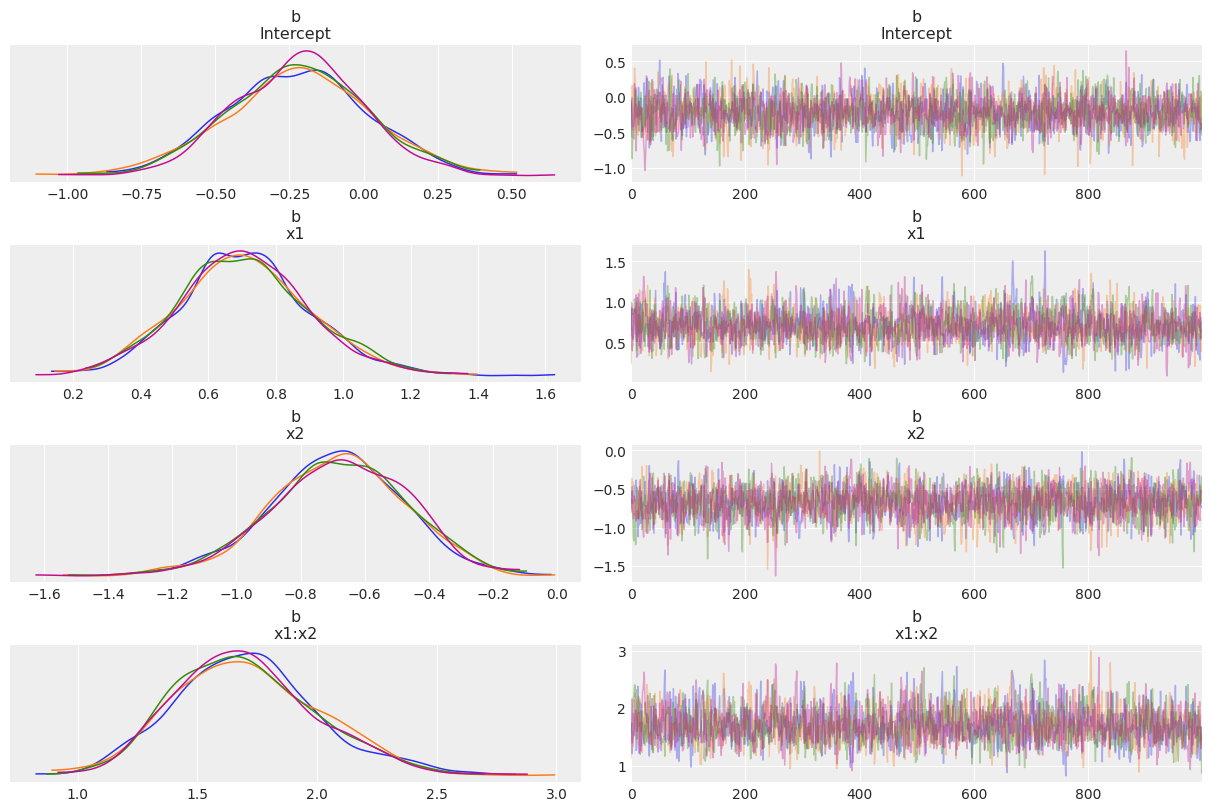

In [10]:
az.plot_trace(idata, var_names="b", compact=False);

In [11]:
az.summary(idata, var_names="b")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b[Intercept],-0.221,0.234,-0.686,0.195,0.005,0.004,2513.0,2595.0,1.0
b[x1],0.708,0.195,0.351,1.092,0.004,0.003,2469.0,2683.0,1.0
b[x2],-0.681,0.209,-1.068,-0.285,0.004,0.003,2786.0,2877.0,1.0
b[x1:x2],1.705,0.302,1.172,2.286,0.006,0.005,2212.0,2493.0,1.0


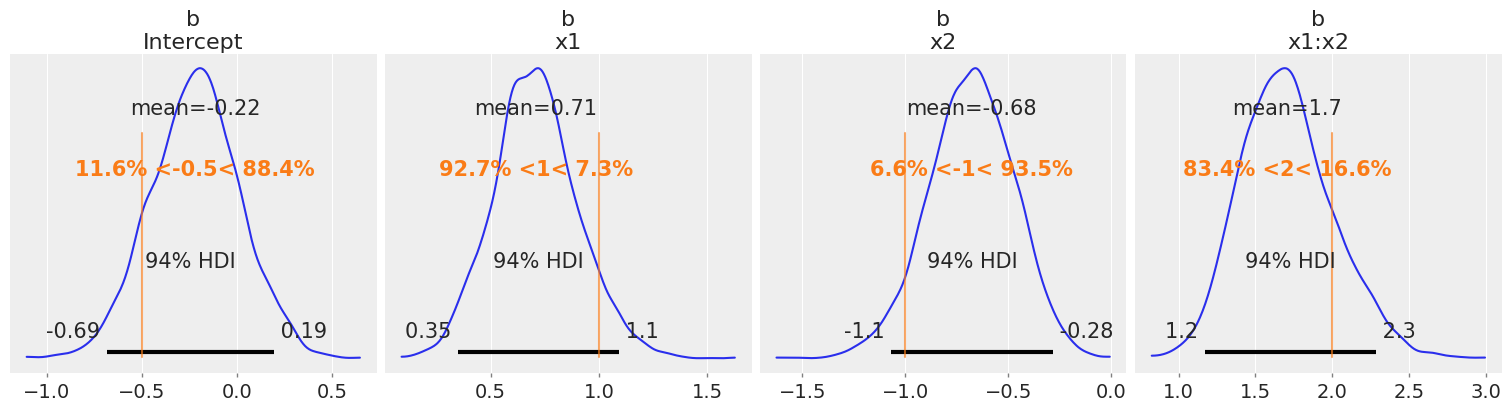

In [12]:
az.plot_posterior(
    idata, var_names=["b"], ref_val=[intercept, beta_x1, beta_x2, beta_interaction], figsize=(15, 4)
);

In [13]:
with model:
    pm.set_data({"X": x_test, "y": y_test})
    idata.extend(pm.sample_posterior_predictive(idata))

Sampling: [obs]


In [14]:
# Compute the point prediction by taking the mean and defining the category via a threshold.
p_test_pred = idata.posterior_predictive["obs"].mean(dim=["chain", "draw"])
y_test_pred = (p_test_pred >= 0.5).astype("int").to_numpy()

In [15]:
print(f"accuracy = {np.mean(y_test==y_test_pred): 0.3f}")

accuracy =  0.907


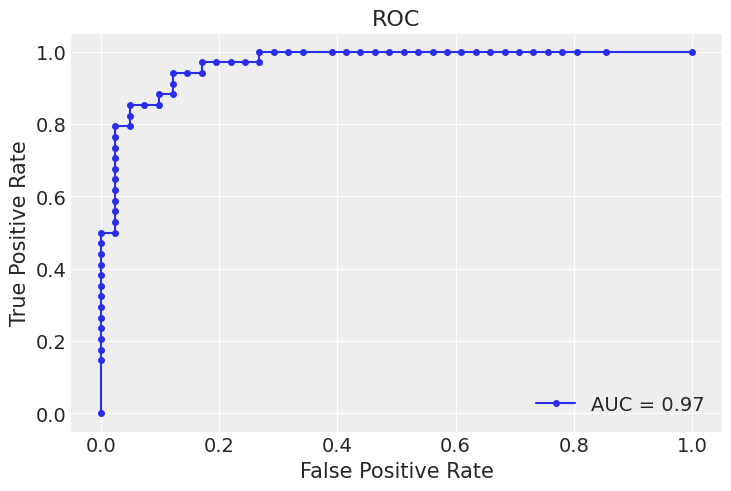

In [16]:
fpr, tpr, thresholds = roc_curve(
    y_true=y_test, y_score=p_test_pred, pos_label=1, drop_intermediate=False
)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display = roc_display.plot(ax=ax, marker="o", markersize=4)
ax.set(title="ROC");

In [17]:
def make_grid():
    x1_grid = np.linspace(start=-9, stop=9, num=300)
    x2_grid = x1_grid
    x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.stack(arrays=[x1_mesh.flatten(), x2_mesh.flatten()], axis=1)
    return x1_grid, x2_grid, x_grid


x1_grid, x2_grid, x_grid = make_grid()

with model:
    # Create features on the grid.
    x_grid_ext = np.hstack(
        (
            np.ones((x_grid.shape[0], 1)),
            x_grid,
            (x_grid[:, 0] * x_grid[:, 1]).reshape(-1, 1),
        )
    )
    # set the observed variables
    pm.set_data({"X": x_grid_ext})
    # calculate pushforward values of `p`
    ppc_grid = pm.sample_posterior_predictive(idata, var_names=["p"])

Sampling: []


In [18]:
# grid of predictions
grid_df = pd.DataFrame(x_grid, columns=["x1", "x2"])
grid_df["p"] = ppc_grid.posterior_predictive.p.mean(dim=["chain", "draw"])
p_grid = grid_df.pivot(index="x2", columns="x1", values="p").to_numpy()

In [19]:
def calc_decision_boundary(idata, x1_grid):
    # posterior mean of coefficients
    intercept = idata.posterior["b"].sel(coeffs="Intercept").mean().data
    b1 = idata.posterior["b"].sel(coeffs="x1").mean().data
    b2 = idata.posterior["b"].sel(coeffs="x2").mean().data
    b1b2 = idata.posterior["b"].sel(coeffs="x1:x2").mean().data
    # decision boundary equation
    return -(intercept + b1 * x1_grid) / (b2 + b1b2 * x1_grid)

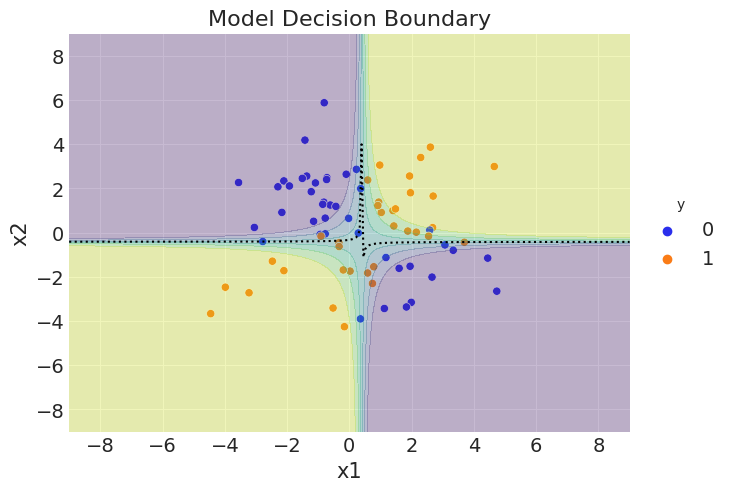

In [20]:
fig, ax = plt.subplots()

# data
sns.scatterplot(
    x=x_test[:, 1].flatten(),
    y=x_test[:, 2].flatten(),
    hue=y_test,
    ax=ax,
)

# decision boundary
ax.plot(x1_grid, calc_decision_boundary(idata, x1_grid), color="black", linestyle=":")

# grid of predictions
ax.contourf(x1_grid, x2_grid, p_grid, alpha=0.3)

ax.legend(title="y", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Model Decision Boundary", xlim=(-9, 9), ylim=(-9, 9), xlabel="x1", ylabel="x2");

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma2, beta, intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


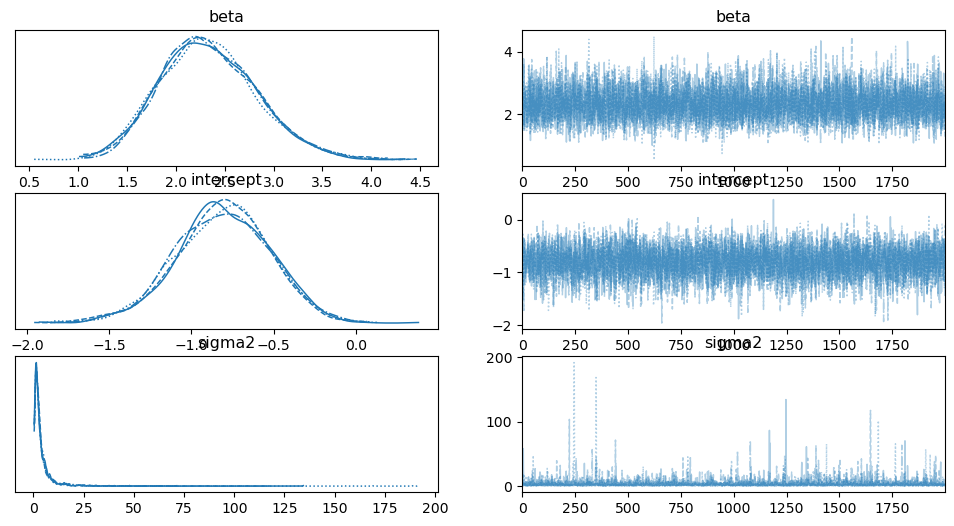

Sampling: [Y_obs]


Output()

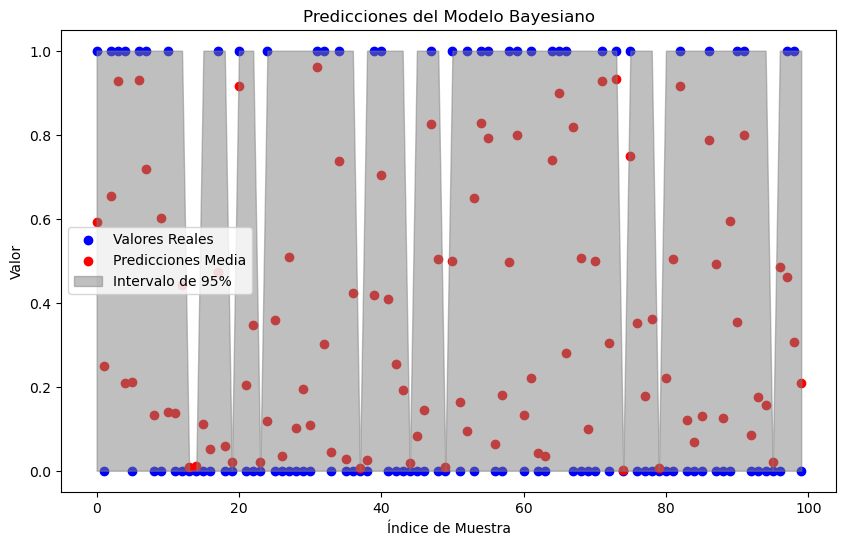

In [7]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Generar datos simulados
np.random.seed(42)
n_samples = 100
X = np.random.normal(0, 1, n_samples)  # Variable independiente
# Coeficientes verdaderos
beta_true = 2.0
intercept_true = -0.5
# Generar variable dependiente binaria con ruido
p = 1 / (1 + np.exp(-(intercept_true + beta_true * X)))
Y = np.random.binomial(1, p)

# Definir el modelo bayesiano
with pm.Model() as logistic_model:
    # Prior para la varianza desconocida (Inversa-Gamma)
    sigma2 = pm.InverseGamma('sigma2', alpha=1, beta=1)
    sigma = pm.math.sqrt(sigma2)
    
    # Priors para los coeficientes de la regresión
    beta = pm.Normal('beta', mu=0, sigma=sigma)
    intercept = pm.Normal('intercept', mu=0, sigma=sigma)
    
    # Likelihood usando la función logística
    p = pm.Deterministic('p', 1 / (1 + pm.math.exp(-(intercept + beta * X))))
    likelihood = pm.Bernoulli('Y_obs', p=p, observed=Y)
    
    # Muestreo con MCMC
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

# Resumen de la posterior
az.summary(trace, var_names=['beta', 'intercept', 'sigma2'])

# Graficar las trazas de las muestras
az.plot_trace(trace, var_names=['beta', 'intercept', 'sigma2'])
plt.show()

# Muestreo posterior predictivo
with logistic_model:
    posterior_pred = pm.sample_posterior_predictive(trace, var_names=['Y_obs'], return_inferencedata=True)

# Usar directamente el objeto `posterior_pred` como `idata`
idata = posterior_pred

# Extraer las predicciones y calcular estadísticas
mean_preds = idata.posterior_predictive['Y_obs'].mean(dim=["chain", "draw"])
lower_preds = idata.posterior_predictive['Y_obs'].quantile(0.025, dim=["chain", "draw"])
upper_preds = idata.posterior_predictive['Y_obs'].quantile(0.975, dim=["chain", "draw"])

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(range(len(Y)), Y, c='blue', label='Valores Reales')
plt.scatter(range(len(Y)), mean_preds, c='red', label='Predicciones Media')
plt.fill_between(range(len(Y)), lower_preds, upper_preds, color='gray', alpha=0.5, label='Intervalo de 95%')
plt.xlabel('Índice de Muestra')
plt.ylabel('Valor')
plt.legend()
plt.title('Predicciones del Modelo Bayesiano')
plt.show()


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]
python(60874) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(60875) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(60876) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Output()

python(60877) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Sampling 4 chains for 1_000 tune and 20_000 draw iterations (4_000 + 80_000 draws total) took 11 seconds.
Sampling: [Y_obs]


Output()

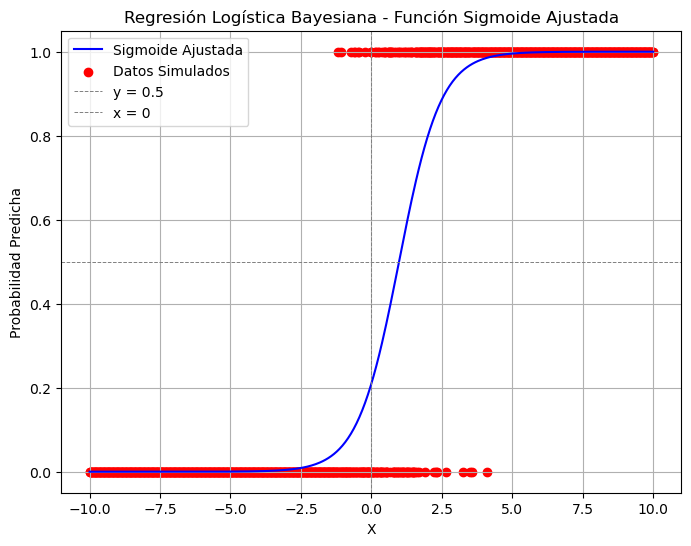

In [15]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
# Generar datos simulados
np.random.seed(42)
n_samples = 1000
X = np.linspace(-10, 10, n_samples)
# Coeficientes verdaderos
beta_true = 1.5
intercept_true = -2.0

# Calcular la probabilidad verdadera usando la función sigmoide
p_true = 1 / (1 + np.exp(-(intercept_true + beta_true * X)))

# Generar etiquetas binarias con ruido basado en la probabilidad verdadera
Y = np.random.binomial(1, p_true)
# Definir el modelo bayesiano
with pm.Model() as logistic_model:
    # Priors para los coeficientes de la regresión logística
    beta = pm.Normal('beta', mu=0, sigma=5)
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    
    # Modelo logístico
    p = pm.Deterministic('p', 1 / (1 + pm.math.exp(-(intercept + beta * X))))
    
    # Likelihood (Verosimilitud) usando la distribución Bernoulli
    Y_obs = pm.Bernoulli('Y_obs', p=p, observed=Y)
    
    # Muestreo de la posterior
    trace = pm.sample(20000, tune=1000, return_inferencedata=True)

# Resumen de la posterior
az.summary(trace, var_names=['beta', 'intercept'])

# Muestreo posterior predictivo
with logistic_model:
    posterior_pred = pm.sample_posterior_predictive(trace, var_names=['Y_obs'], return_inferencedata=True)

# Calcular la sigmoide basada en la media de la posterior
X_test = np.linspace(-10, 10, 400)
beta_mean = trace.posterior['beta'].mean().item()
intercept_mean = trace.posterior['intercept'].mean().item()
Y_pred_proba = 1 / (1 + np.exp(-(intercept_mean + beta_mean * X_test)))

# Graficar la función sigmoide ajustada por la regresión logística bayesiana
plt.figure(figsize=(8, 6))
plt.plot(X_test, Y_pred_proba, label='Sigmoide Ajustada', color='blue')
plt.scatter(X, Y, c='red', marker='o', label='Datos Simulados')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, label='y = 0.5')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7, label='x = 0')
plt.xlabel('X')
plt.ylabel('Probabilidad Predicha')
plt.title('Regresión Logística Bayesiana - Función Sigmoide Ajustada')
plt.legend()
plt.grid()
plt.show()


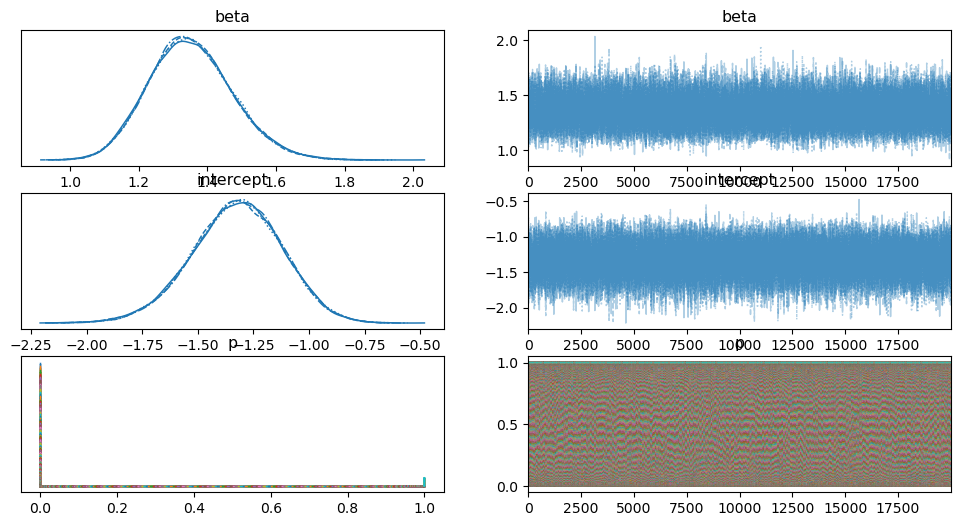

In [16]:
# Resumen de la posterior
az.summary(trace)

# Graficar las trazas de las muestras
az.plot_trace(trace)
plt.show()
